#Health&Life Analytics

A empresa Health&Life Analytics precisa entender melhor o perfil dos clientes e como o consumo de café se relaciona com aspectos de saúde.

#Leitura Banco de Dados e Bibliotecas

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
dados  = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Alura/Cientista de Dados - Nível 1/Checkpoint Cientista de Dados - Nível 1/synthetic_coffee_health_10000(in).csv')

In [89]:
dados

,ID,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Health_Issues,Occupation,Smoking,Alcohol_Consumption
0,1,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,NaN,Other,0,0
1,2,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,NaN,Service,0,0
2,3,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Mild,Office,0,0
3,4,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Mild,Other,0,0
4,5,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Mild,Student,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,50,Female,Japan,2.1,199.8,6.0,Fair,30.5,50,Medium,10.1,Moderate,Healthcare,0,1
9996,9997,18,Female,UK,3.4,319.2,5.8,Fair,19.1,71,Medium,11.6,Mild,Service,0,0
9997,9998,26,Male,China,1.6,153.4,7.1,Good,25.1,66,Low,13.7,NaN,Student,1,1
9998,9999,40,Female,Finland,3.4,327.1,7.0,Good,19.3,80,Low,0.1,NaN,Student,0,0


# Dicionário de Dados

## Descrição das colunas

- **ID**: Identificador único de cada registro (1–10000)

- **Age**: Idade do participante (18 a 80 anos)

- **Gender**: Gênero  
  Valores possíveis: Male, Female, Other

- **Country**: País de residência (20 países representados)

- **Coffee_Intake**: Consumo diário de café em xícaras (0 a 10)

- **Caffeine_mg**: Estimativa de cafeína ingerida por dia (mg)  
  (1 xícara ≈ 95 mg)

- **Sleep_Hours**: Média de horas de sono por noite (3 a 10 horas)

- **Sleep_Quality**: Qualidade do sono  
  Valores possíveis: Poor, Fair, Good, Excellent

- **BMI**: Índice de Massa Corporal (15 a 40)

- **Heart_Rate**: Frequência cardíaca em repouso (50 a 110 bpm)

- **Stress_Level**: Nível de estresse  
  Valores possíveis: Low, Medium, High

- **Physical_Activity_Hours**: Tempo de atividade física semanal (0 a 15 horas)

- **Health_Issues**: Condições de saúde  
  Valores possíveis: None, Mild, Moderate, Severe

- **Occupation**: Ocupação principal  
  Valores possíveis: Office, Healthcare, Student, Service, Other

- **Smoking**: Indica se o participante é fumante  
  0 = Não, 1 = Sim

- **Alcohol_Consumption**: Indica se consome álcool  
  0 = Não, 1 = Sim

#Análise Exploratória de Dados

In [90]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       10000 non-null  int64  
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   Country                  10000 non-null  object 
 4   Coffee_Intake            10000 non-null  float64
 5   Caffeine_mg              10000 non-null  float64
 6   Sleep_Hours              10000 non-null  float64
 7   Sleep_Quality            10000 non-null  object 
 8   BMI                      10000 non-null  float64
 9   Heart_Rate               10000 non-null  int64  
 10  Stress_Level             10000 non-null  object 
 11  Physical_Activity_Hours  10000 non-null  float64
 12  Health_Issues            4059 non-null   object 
 13  Occupation               10000 non-null  object 
 14  Smoking                

In [91]:
print("Dimensões (linhas, colunas):", dados.shape)
print("\nValores nulos por coluna:")
print(dados.isnull().sum())
print("\nLinhas duplicadas:", dados.duplicated().sum())

Dimensões (linhas, colunas): (10000, 16)

Valores nulos por coluna:
ID                            0
Age                           0
Gender                        0
Country                       0
Coffee_Intake                 0
Caffeine_mg                   0
Sleep_Hours                   0
Sleep_Quality                 0
BMI                           0
Heart_Rate                    0
Stress_Level                  0
Physical_Activity_Hours       0
Health_Issues              5941
Occupation                    0
Smoking                       0
Alcohol_Consumption           0
dtype: int64

Linhas duplicadas: 0


In [92]:
dados.describe()

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000
mean,5000.50000,34.949100,2.509230,238.411010,6.636220,23.986860,70.617800,7.48704,0.20040,0.300700
std,2886.89568,11.160939,1.450248,137.748815,1.222055,3.906411,9.822951,4.31518,0.40032,0.458585
min,1.00000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.00000,0.000000
25%,2500.75000,26.000000,1.500000,138.750000,5.800000,21.300000,64.000000,3.70000,0.00000,0.000000
50%,5000.50000,34.000000,2.500000,235.400000,6.600000,24.000000,71.000000,7.50000,0.00000,0.000000
75%,7500.25000,43.000000,3.500000,332.025000,7.500000,26.600000,77.000000,11.20000,0.00000,1.000000
max,10000.00000,80.000000,8.200000,780.300000,10.000000,38.200000,109.000000,15.00000,1.00000,1.000000


Boxplots simples para outliers

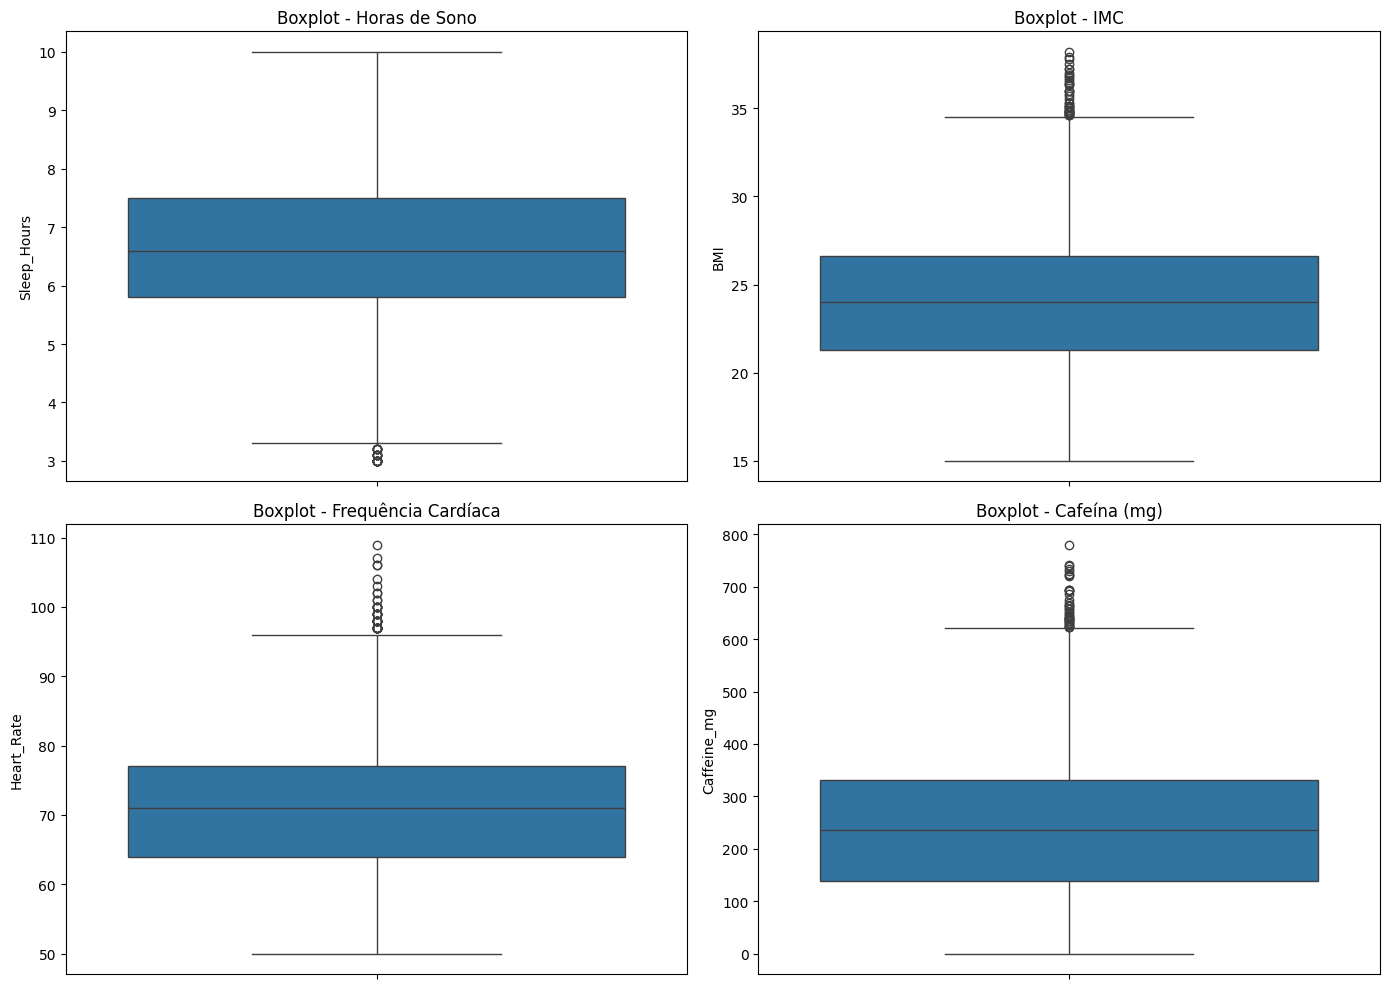

In [93]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(y=dados['Sleep_Hours'], ax=axes[0,0])
axes[0,0].set_title('Boxplot - Horas de Sono')

sns.boxplot(y=dados['BMI'], ax=axes[0,1])
axes[0,1].set_title('Boxplot - IMC')

sns.boxplot(y=dados['Heart_Rate'], ax=axes[1,0])
axes[1,0].set_title('Boxplot - Frequência Cardíaca')

sns.boxplot(y=dados['Caffeine_mg'], ax=axes[1,1])
axes[1,1].set_title('Boxplot - Cafeína (mg)')

plt.tight_layout()
plt.show()

Boxplots por genero

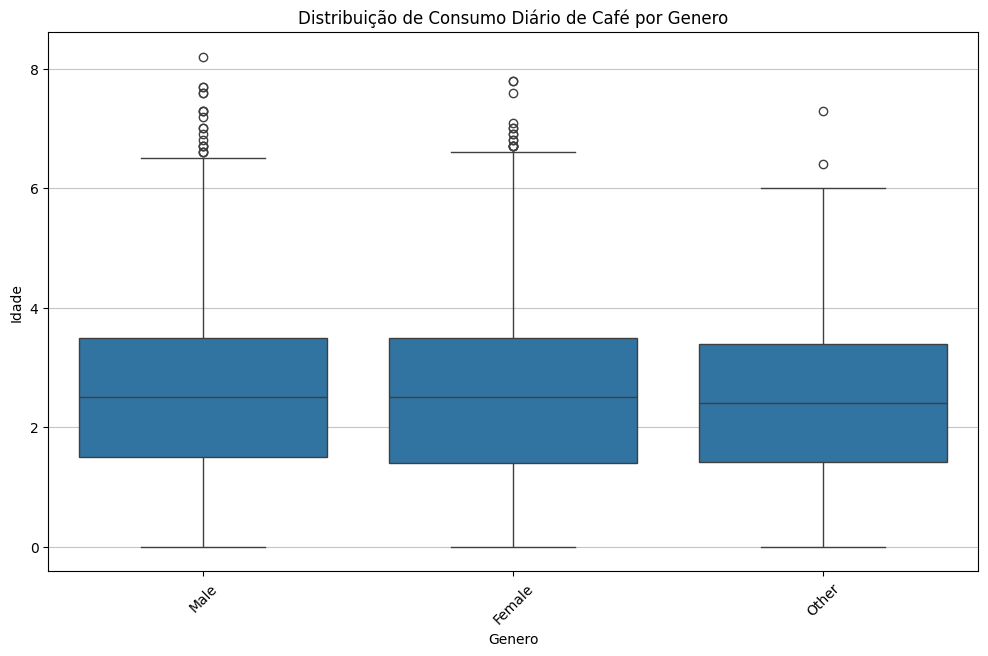

In [94]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Gender', y='Coffee_Intake', data=dados)
plt.title('Distribuição de Consumo Diário de Café por Genero')
plt.xlabel('Genero')
plt.ylabel('Idade')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.75)
plt.show()

In [95]:
display(dados[dados['Gender'] == 'Male'].describe())

,ID,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,BMI,Heart_Rate,Physical_Activity_Hours,Smoking,Alcohol_Consumption
count,4773.000000,4773.000000,4773.000000,4773.000000,4773.000000,4773.000000,4773.000000,4773.00000,4773.000000,4773.000000
mean,4923.514142,34.887283,2.522208,239.638026,6.637503,24.020553,70.567568,7.49472,0.195684,0.297297
std,2895.521336,11.094063,1.448332,137.547155,1.224720,3.883596,9.848256,4.32974,0.396768,0.457116
min,1.000000,18.000000,0.000000,0.000000,3.000000,15.000000,50.000000,0.00000,0.000000,0.000000
25%,2395.000000,27.000000,1.500000,141.100000,5.800000,21.300000,64.000000,3.80000,0.000000,0.000000
50%,4937.000000,34.000000,2.500000,237.900000,6.600000,24.000000,71.000000,7.50000,0.000000,0.000000
75%,7434.000000,43.000000,3.500000,332.800000,7.500000,26.700000,77.000000,11.30000,0.000000,1.000000
max,9998.000000,80.000000,8.200000,780.300000,10.000000,37.900000,106.000000,15.00000,1.000000,1.000000


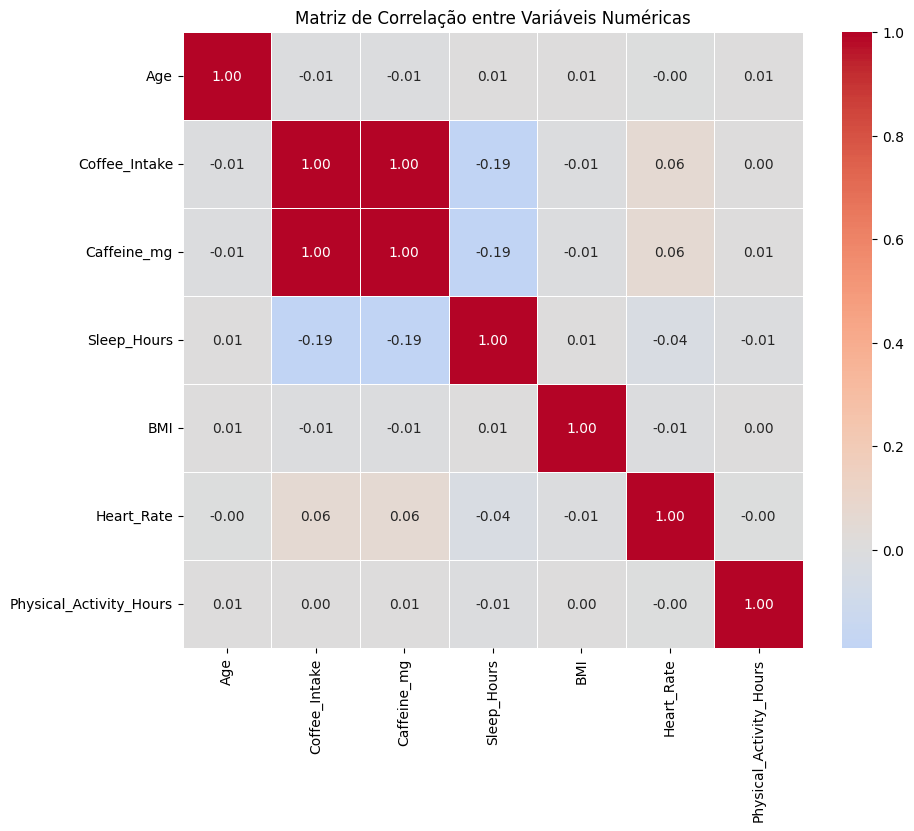

In [96]:
colunas_numericas = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours',
                      'BMI', 'Heart_Rate', 'Physical_Activity_Hours']

matriz_corr = dados[colunas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas')
plt.show()

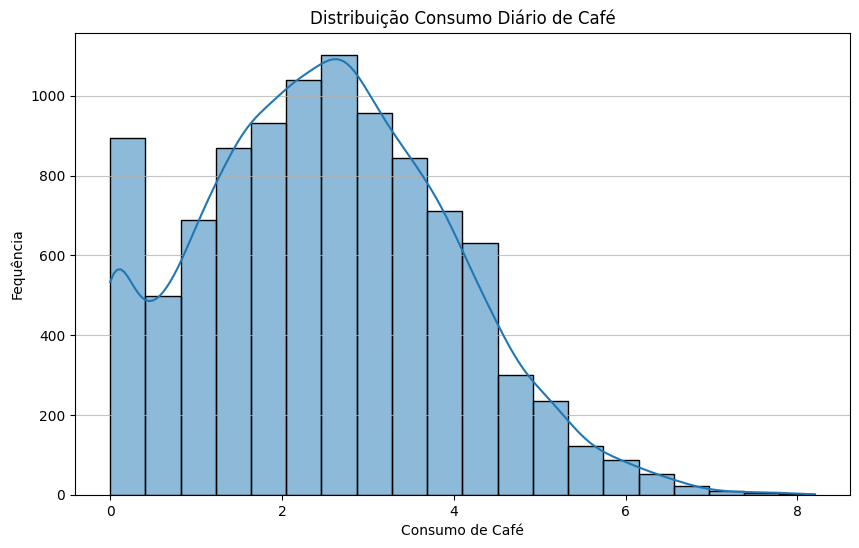

In [97]:
plt.figure(figsize=(10, 6))
sns.histplot(dados['Coffee_Intake'], bins=20, kde=True)
plt.title('Distribuição Consumo Diário de Café')
plt.xlabel('Consumo de Café')
plt.ylabel('Fequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

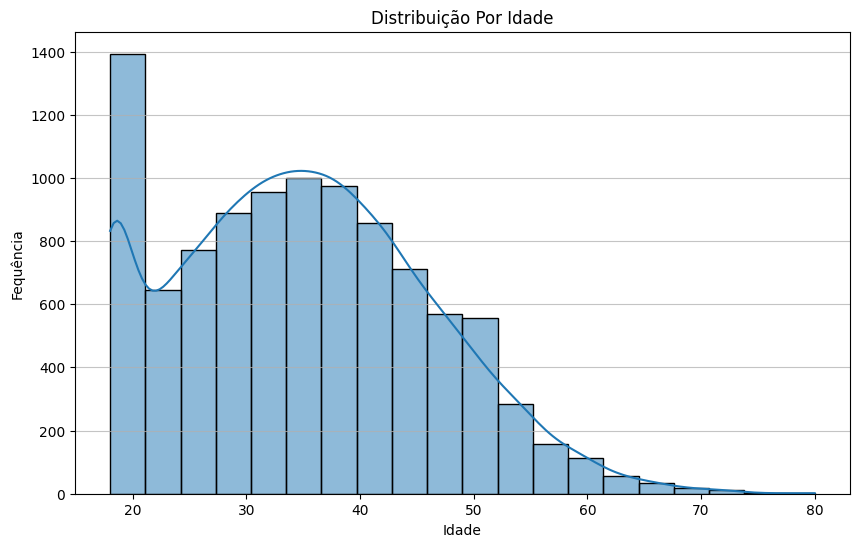

In [98]:
plt.figure(figsize=(10, 6))
sns.histplot(dados['Age'], bins=20, kde=True)
plt.title('Distribuição Por Idade')
plt.xlabel('Idade')
plt.ylabel('Fequência')
plt.grid(axis='y', alpha=0.75)
plt.show()

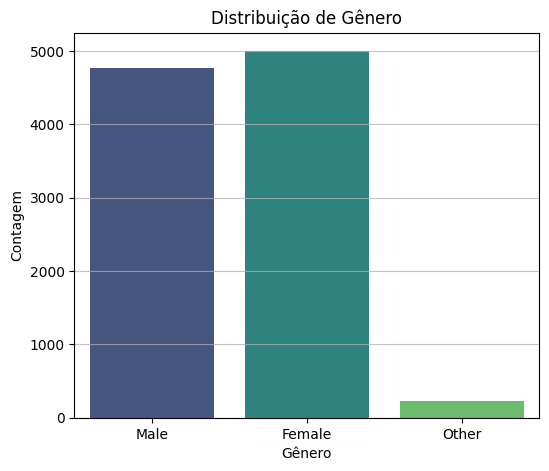

Gender
Female    5001
Male      4773
Other      226
Name: count, dtype: int64


In [99]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Gender', data=dados, palette='viridis', hue='Gender', legend=False)
plt.title('Distribuição de Gênero')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.grid(axis='y', alpha=0.75)
plt.show()

print(dados['Gender'].value_counts())

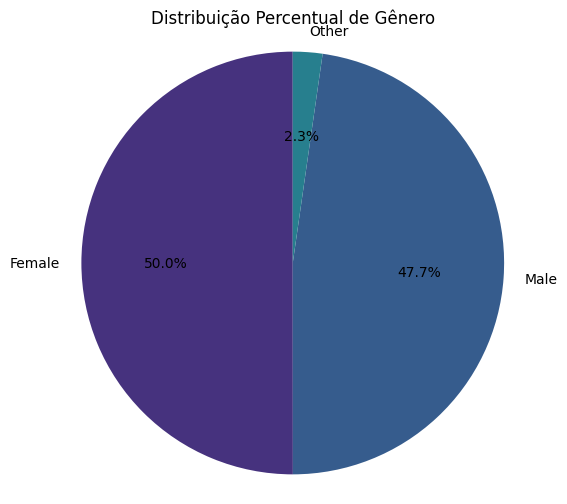

In [100]:
gender_counts = dados['Gender'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis'))
plt.title('Distribuição Percentual de Gênero')
plt.axis('equal')
plt.show()

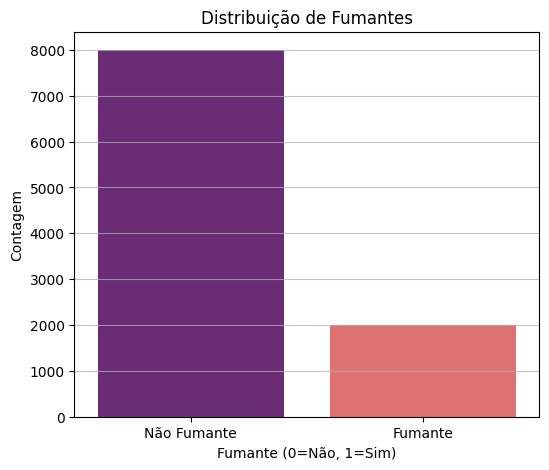

In [101]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Smoking', data=dados, palette='magma', hue='Smoking', legend=False)
plt.title('Distribuição de Fumantes')
plt.xlabel('Fumante (0=Não, 1=Sim)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Não Fumante', 'Fumante'])
plt.grid(axis='y', alpha=0.75)
plt.show()

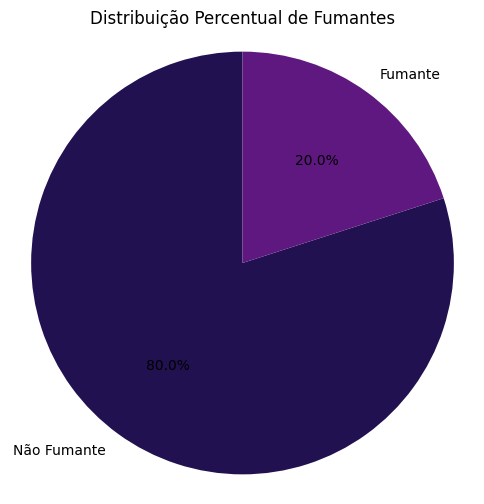

In [102]:
smoking_counts = dados['Smoking'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(smoking_counts, labels=['Não Fumante', 'Fumante'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('magma'))
plt.title('Distribuição Percentual de Fumantes')
plt.axis('equal')
plt.show()

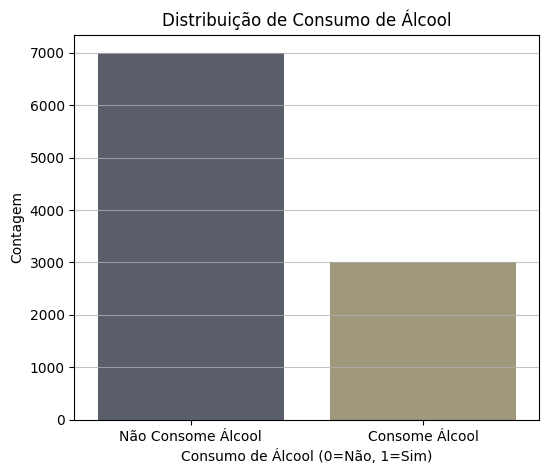

In [103]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Alcohol_Consumption', data=dados, palette='cividis', hue='Alcohol_Consumption', legend=False)
plt.title('Distribuição de Consumo de Álcool')
plt.xlabel('Consumo de Álcool (0=Não, 1=Sim)')
plt.ylabel('Contagem')
plt.xticks([0, 1], ['Não Consome Álcool', 'Consome Álcool'])
plt.grid(axis='y', alpha=0.75)
plt.show()

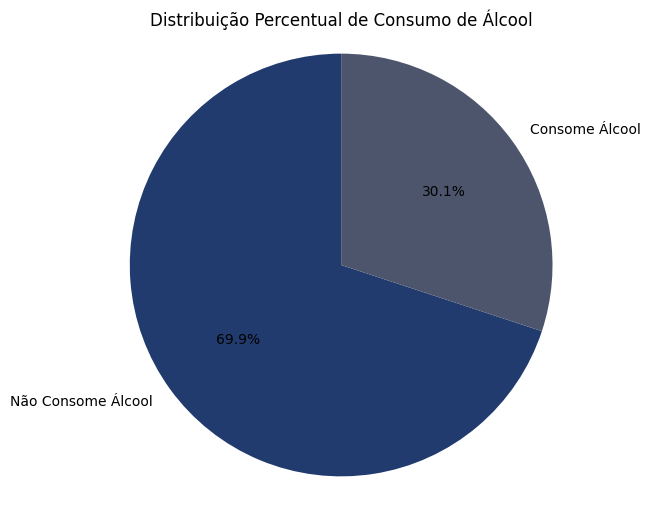

In [104]:
alcohol_counts = dados['Alcohol_Consumption'].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(alcohol_counts, labels=['Não Consome Álcool', 'Consome Álcool'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('cividis'))
plt.title('Distribuição Percentual de Consumo de Álcool')
plt.axis('equal')
plt.show()

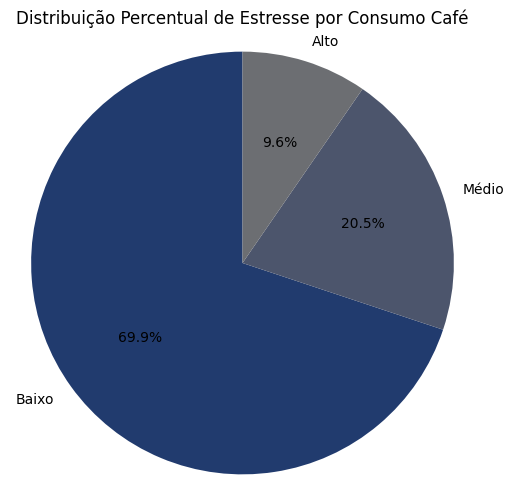

In [105]:
alcohol_counts = dados['Stress_Level'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(alcohol_counts, labels=['Baixo', 'Médio', 'Alto'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('cividis'))
plt.title('Distribuição Percentual de Estresse por Consumo Café')
plt.axis('equal')
plt.show()

#Visualização e Insights

###Gráfico 01: Sono por gênero

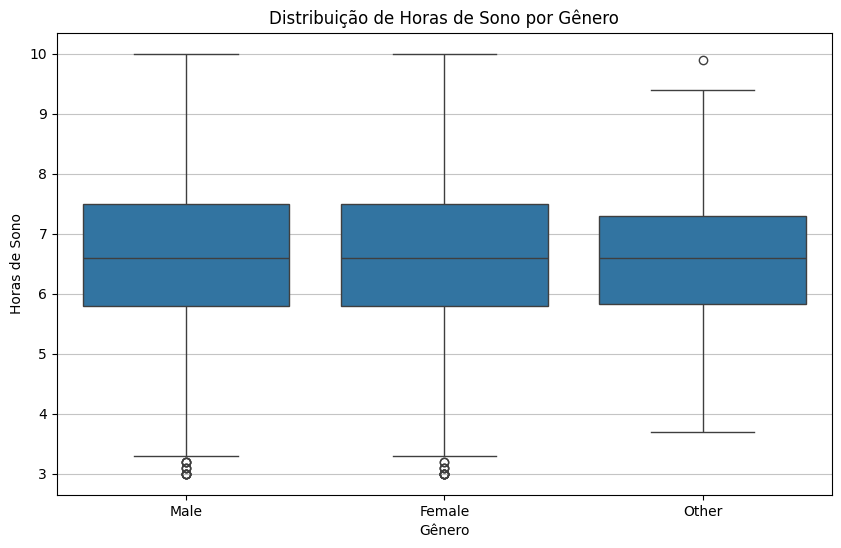


Estatísticas descritivas das Horas de Sono por Gênero:
         count      mean      std  min    25%  50%  75%   max
Gender                                                       
Female  5001.0  6.636933  1.22109  3.0  5.800  6.6  7.5  10.0
Male    4773.0  6.637503  1.22472  3.0  5.800  6.6  7.5  10.0
Other    226.0  6.593363  1.19119  3.7  5.825  6.6  7.3   9.9


In [106]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Gender', y='Sleep_Hours', data=dados)
plt.title('Distribuição de Horas de Sono por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Horas de Sono')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nEstatísticas descritivas das Horas de Sono por Gênero:")
print(dados.groupby('Gender')['Sleep_Hours'].describe())

###Gráfico 02: Estresse e Sono

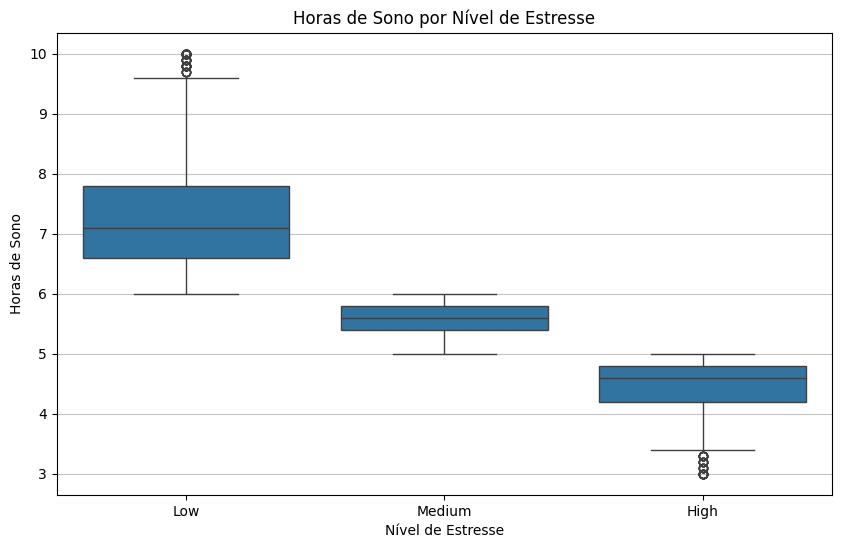


Horas de Sono por Nível de Estresse:
               count      mean       std  min  25%  50%  75%   max
Stress_Level                                                      
High           961.0  4.451925  0.456320  3.0  4.2  4.6  4.8   5.0
Low           6989.0  7.247332  0.852397  6.0  6.6  7.1  7.8  10.0
Medium        2050.0  5.576732  0.278688  5.0  5.4  5.6  5.8   6.0


In [107]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Stress_Level', y='Sleep_Hours', data=dados, order=['Low', 'Medium', 'High'])
plt.title('Horas de Sono por Nível de Estresse')
plt.xlabel('Nível de Estresse')
plt.ylabel('Horas de Sono')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nHoras de Sono por Nível de Estresse:")
print(dados.groupby('Stress_Level')['Sleep_Hours'].describe())

###Gráfico 03: Estresse e consumo de café

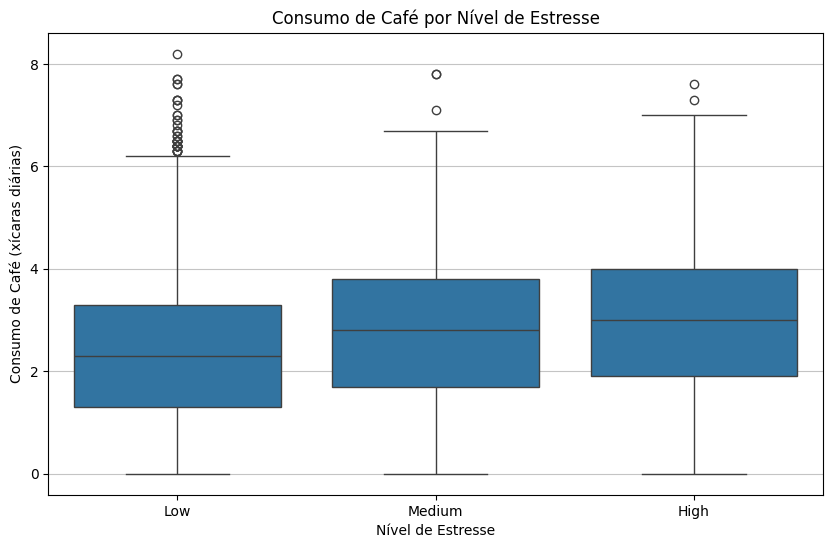


Consumo de Café por Nível de Estresse:
               count      mean       std  min  25%  50%  75%  max
Stress_Level                                                     
High           961.0  2.979396  1.493727  0.0  1.9  3.0  4.0  7.6
Low           6989.0  2.369838  1.417693  0.0  1.3  2.3  3.3  8.2
Medium        2050.0  2.764049  1.459039  0.0  1.7  2.8  3.8  7.8


In [108]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Stress_Level', y='Coffee_Intake', data=dados, order=['Low', 'Medium', 'High'])
plt.title('Consumo de Café por Nível de Estresse')
plt.xlabel('Nível de Estresse')
plt.ylabel('Consumo de Café (xícaras diárias)')
plt.grid(axis='y', alpha=0.75)
plt.show()

print("\nConsumo de Café por Nível de Estresse:")
print(dados.groupby('Stress_Level')['Coffee_Intake'].describe())

Comparando Gráficos 02 e 03 para correlação

In [109]:
print("Média de horas de sono por nível de estresse:")
print(dados.groupby('Stress_Level')['Sleep_Hours'].mean().reindex(['Low', 'Medium', 'High']))

print("\nMédia de consumo de café por nível de estresse:")
print(dados.groupby('Stress_Level')['Coffee_Intake'].mean().reindex(['Low', 'Medium', 'High']))

Média de horas de sono por nível de estresse:
Stress_Level
Low       7.247332
Medium    5.576732
High      4.451925
Name: Sleep_Hours, dtype: float64

Média de consumo de café por nível de estresse:
Stress_Level
Low       2.369838
Medium    2.764049
High      2.979396
Name: Coffee_Intake, dtype: float64


###Gráfico 04: Idade, estresse e café combinados

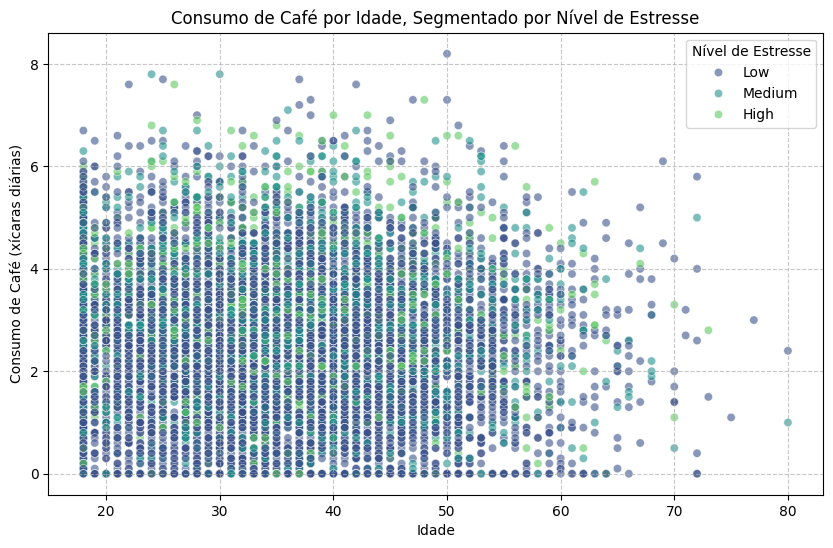

In [110]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='Coffee_Intake', hue='Stress_Level', hue_order=['Low', 'Medium', 'High'], data=dados, alpha=0.6, palette='viridis')
plt.title('Consumo de Café por Idade, Segmentado por Nível de Estresse')
plt.xlabel('Idade')
plt.ylabel('Consumo de Café (xícaras diárias)')
plt.legend(title='Nível de Estresse')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Principais Descobertas

**Gráfico 1: Sono por Gênero**

As três caixas (Male, Female, Other) estão praticamente na mesma altura, com mediana em torno de 6.6h nos três grupos, mesma faixa de quartis. A única diferença visível é que "Other" tem menos outliers na parte baixa.
Não há diferença relevante de sono entre gêneros.

**Gráfico 2: Estresse e Sono**

Conforme o estresse sobe (Low, Medium e High), a caixa inteira desce. Onde a mediana em Low está por volta de 7.1h, em Medium por volta de 5.6h, em High por volta de 4.6h.

**Imagem 3 — Estresse e consumo de café**

A mediana de consumo de café sobe de ~2.3 (Low) para ~2.8 (Medium) para ~3.0 (High), e a caixa toda desloca um pouco pra cima. É uma relação mais fraca que a do estresse com sono, mas as caixas se sobrepõem bastante, então tem gente com estresse alto bebendo pouco café e assim por diante.

**Imagem 4 — Idade, estresse e café combinados**

As três cores (Low, Medium, High) estão bem misturadas por toda a faixa etária, sem um cluster óbvio de uma cor num canto específico. Não dá para ver visualmente uma interação clara entre idade e estresse influenciando o consumo de café. O padrão de café por estresse observado na *Imagem 3* parece se manter parecido em todas as idades, sem idade "amplificar" ou "reduzir" esse efeito de forma visível.

#Conclusão Geral

Ao analisar os quatro gráficos em conjunto, o estresse se destaca como o fator
mais relevante associado ao sono dos clientes, enquanto gênero e idade não
mostraram influência significativa. O consumo de café aparece como um fator
secundário: existe uma tendência de aumento junto com o estresse, mas de forma
bem mais fraca do que a relação direta entre estresse e sono.

**Insights de negócio:**

- Clientes com nível de estresse alto dormem, em média, **4,45 horas** por
noite, contra **7,25 horas** entre os clientes com estresse baixo, sendo uma
diferença de quase **2,8 horas de sono**. O nível de estresse é o fator que
mais altera a quantidade de sono dos clientes neste conjunto de dados.

- O consumo de café também aumenta com o estresse (de 2,37 para 2,98 xícaras
em média), mas essa variação é pequena se comparada à queda no sono, sugerindo
que o café acompanha o estresse sem ser sua causa principal.

- Não foram observadas diferenças relevantes de sono entre gêneros, nem uma
interação clara entre idade e estresse no consumo de café. O que indica que,
para ações de negócio voltadas à melhoria do sono dos clientes, o estresse
deve ser o foco prioritário, à frente de fatores como consumo de café, gênero
ou idade.

#Modelo preditivo

Vamos criar um modelo preditivo para que possamos prever a **qualidade do sono (Sleep_Quality)** com base nos hábitos e características dos clientes.

##Pré-processamento

In [111]:
#Removendo ID (identificadores) e Health_Issues (com a maioria das células como Nulo)

dados_modelo = dados.drop(columns=['ID', 'Health_Issues'])
dados_modelo.head()

,Age,Gender,Country,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Occupation,Smoking,Alcohol_Consumption
0,40,Male,Germany,3.5,328.1,7.5,Good,24.9,78,Low,14.5,Other,0,0
1,33,Male,Germany,1.0,94.1,6.2,Good,20.0,67,Low,11.0,Service,0,0
2,42,Male,Brazil,5.3,503.7,5.9,Fair,22.7,59,Medium,11.2,Office,0,0
3,53,Male,Germany,2.6,249.2,7.3,Good,24.7,71,Low,6.6,Other,0,0
4,32,Female,Spain,3.1,298.0,5.3,Fair,24.1,76,Medium,8.5,Student,0,1


In [112]:
print(dados_modelo['Sleep_Quality'].unique())
print(dados_modelo['Stress_Level'].unique())

['Good' 'Fair' 'Excellent' 'Poor']
['Low' 'Medium' 'High']


In [113]:
# Codificação ordinal para Stress_Level (tem ordem natural)
stress_map = {'Low': 0, 'Medium': 1, 'High': 2}
dados_modelo['Stress_Level'] = dados_modelo['Stress_Level'].map(stress_map)

# Codificação ordinal para o alvo Sleep_Quality (tem ordem de qualidade)
sleep_quality_map = {'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}
dados_modelo['Sleep_Quality'] = dados_modelo['Sleep_Quality'].map(sleep_quality_map)

# One-hot encoding para as categóricas sem ordem
dados_modelo = pd.get_dummies(dados_modelo, columns=['Gender', 'Country', 'Occupation'], drop_first=True)

dados_modelo.head()

,Age,Coffee_Intake,Caffeine_mg,Sleep_Hours,Sleep_Quality,BMI,Heart_Rate,Stress_Level,Physical_Activity_Hours,Smoking,...,Country_South Korea,Country_Spain,Country_Sweden,Country_Switzerland,Country_UK,Country_USA,Occupation_Office,Occupation_Other,Occupation_Service,Occupation_Student
0,40,3.5,328.1,7.5,2,24.9,78,0,14.5,0,...,False,False,False,False,False,False,False,True,False,False
1,33,1.0,94.1,6.2,2,20.0,67,0,11.0,0,...,False,False,False,False,False,False,False,False,True,False
2,42,5.3,503.7,5.9,1,22.7,59,1,11.2,0,...,False,False,False,False,False,False,True,False,False,False
3,53,2.6,249.2,7.3,2,24.7,71,0,6.6,0,...,False,False,False,False,False,False,False,True,False,False
4,32,3.1,298.0,5.3,1,24.1,76,1,8.5,0,...,False,True,False,False,False,False,False,False,False,True


In [114]:
dados_modelo.shape

(10000, 36)

In [115]:
# Feature derivada: razão entre consumo de cafeína e horas de sono
# Interpretação: quanto de cafeína a pessoa consome "por hora de sono que ela tem"
dados_modelo['Caffeine_per_Sleep_Hour'] = dados_modelo['Caffeine_mg'] / dados_modelo['Sleep_Hours']

dados_modelo[['Caffeine_mg', 'Sleep_Hours', 'Caffeine_per_Sleep_Hour']].head()

,Caffeine_mg,Sleep_Hours,Caffeine_per_Sleep_Hour
0,328.1,7.5,43.746667
1,94.1,6.2,15.177419
2,503.7,5.9,85.372881
3,249.2,7.3,34.136986
4,298.0,5.3,56.226415


In [116]:
from sklearn.model_selection import train_test_split

X = dados_modelo.drop(columns=['Sleep_Quality'])
y = dados_modelo['Sleep_Quality']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (8000, 36)
Teste: (2000, 36)


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regressão Logística
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train, y_train)

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

print("Modelos treinados com sucesso.")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Modelos treinados com sucesso.


In [118]:
from sklearn.preprocessing import StandardScaler

colunas_numericas_scale = ['Age', 'Coffee_Intake', 'Caffeine_mg', 'Sleep_Hours',
                            'BMI', 'Heart_Rate', 'Physical_Activity_Hours',
                            'Caffeine_per_Sleep_Hour']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas_scale] = scaler.fit_transform(X_train[colunas_numericas_scale])
X_test_scaled[colunas_numericas_scale] = scaler.transform(X_test[colunas_numericas_scale])

# Retreinar a Regressão Logística com dados padronizados
modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

print("Regressão Logística re-treinada com dados padronizados.")

Regressão Logística re-treinada com dados padronizados.


In [119]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Previsões
pred_lr = modelo_lr.predict(X_test_scaled)
pred_rf = modelo_rf.predict(X_test)

# Acurácia
print("Acurácia - Regressão Logística:", accuracy_score(y_test, pred_lr))
print("Acurácia - Random Forest:", accuracy_score(y_test, pred_rf))

Acurácia - Regressão Logística: 0.9915
Acurácia - Random Forest: 0.9925


In [120]:
# Verificar a relação entre Sleep_Hours e Sleep_Quality
dados_modelo.groupby('Sleep_Quality')['Sleep_Hours'].describe()

,count,mean,std,min,25%,50%,75%,max
Sleep_Quality,,,,,,,,
0,961.0,4.451925,0.456320,3.0,4.2,4.6,4.8,5.0
1,2050.0,5.576732,0.278688,5.0,5.4,5.6,5.8,6.0
2,5637.0,6.924446,0.549481,6.0,6.5,6.9,7.4,8.0
3,1352.0,8.593565,0.499959,8.0,8.2,8.5,8.8,10.0


In [121]:
importancias = pd.Series(modelo_rf.feature_importances_, index=X_train.columns)
importancias.sort_values(ascending=False).head(10)

,0
Sleep_Hours,0.515163
Stress_Level,0.337850
Caffeine_per_Sleep_Hour,0.053011
Caffeine_mg,0.021627
Coffee_Intake,0.018240
Physical_Activity_Hours,0.008761
BMI,0.008688
Age,0.007852
Heart_Rate,0.007670
Gender_Male,0.001718


In [122]:
# Remover a coluna que causa vazamento
X = dados_modelo.drop(columns=['Sleep_Quality', 'Sleep_Hours'])
y = dados_modelo['Sleep_Quality']

# Refazer a feature derivada sem depender de Sleep_Hours
# Nova ideia: cafeína por hora de atividade física (não vaza informação do alvo)
X['Caffeine_per_Activity_Hour'] = dados_modelo['Caffeine_mg'] / (dados_modelo['Physical_Activity_Hours'] + 1)
X = X.drop(columns=['Caffeine_per_Sleep_Hour'])

print(X.shape)
print(X.columns.tolist())

(10000, 35)
['Age', 'Coffee_Intake', 'Caffeine_mg', 'BMI', 'Heart_Rate', 'Stress_Level', 'Physical_Activity_Hours', 'Smoking', 'Alcohol_Consumption', 'Gender_Male', 'Gender_Other', 'Country_Belgium', 'Country_Brazil', 'Country_Canada', 'Country_China', 'Country_Finland', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Italy', 'Country_Japan', 'Country_Mexico', 'Country_Netherlands', 'Country_Norway', 'Country_South Korea', 'Country_Spain', 'Country_Sweden', 'Country_Switzerland', 'Country_UK', 'Country_USA', 'Occupation_Office', 'Occupation_Other', 'Occupation_Service', 'Occupation_Student', 'Caffeine_per_Activity_Hour']


**Nota:**
- Detalhe técnico: usei + 1 no denominador porque, diferente de *Sleep_Hours*, *Physical_Activity_Hours* pode ser 0 (isso foi verificado no *.describe()* geral, o mínimo era 0.0), e dividir por zero geraria erro ou infinito. Somar 1 evita isso sem distorcer muito a métrica.

##Novo split treino/teste

In [123]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (8000, 35)
Teste: (2000, 35)


##Padronizar e retreinar Regressão Logística

In [124]:
colunas_numericas_scale = ['Age', 'Coffee_Intake', 'Caffeine_mg',
                            'BMI', 'Heart_Rate', 'Physical_Activity_Hours',
                            'Caffeine_per_Activity_Hour']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[colunas_numericas_scale] = scaler.fit_transform(X_train[colunas_numericas_scale])
X_test_scaled[colunas_numericas_scale] = scaler.transform(X_test[colunas_numericas_scale])

modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

print("Regressão Logística re-treinada.")

Regressão Logística re-treinada.


##Retreinar Random Forest

In [125]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

print("Random Forest re-treinado.")

Random Forest re-treinado.


##Nova avaliação

In [126]:
pred_lr = modelo_lr.predict(X_test_scaled)
pred_rf = modelo_rf.predict(X_test)

print("Acurácia - Regressão Logística:", accuracy_score(y_test, pred_lr))
print("Acurácia - Random Forest:", accuracy_score(y_test, pred_rf))

Acurácia - Regressão Logística: 0.865
Acurácia - Random Forest: 0.864


##Matriz de confusão e relatório de classificação

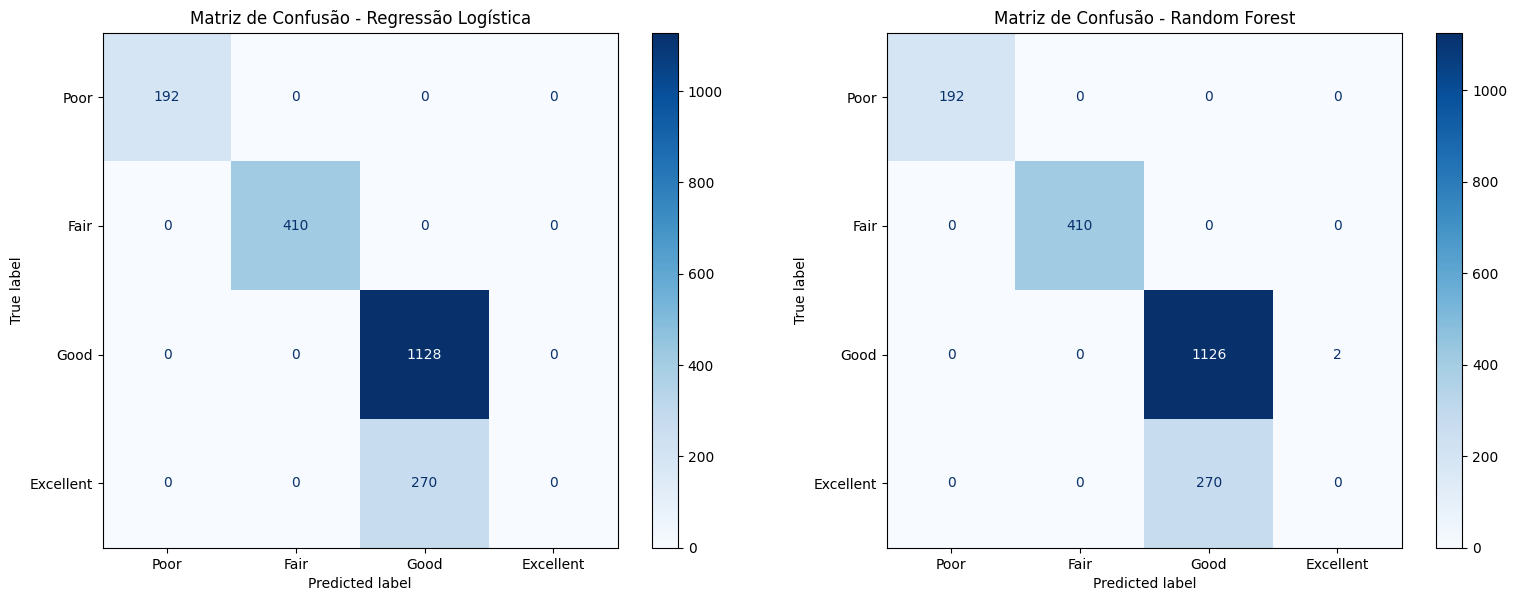

Relatório de Classificação - Regressão Logística:
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.81      1.00      0.89      1128
   Excellent       0.00      0.00      0.00       270

    accuracy                           0.86      2000
   macro avg       0.70      0.75      0.72      2000
weighted avg       0.76      0.86      0.80      2000


Relatório de Classificação - Random Forest:
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.81      1.00      0.89      1128
   Excellent       0.00      0.00      0.00       270

    accuracy                           0.86      2000
   macro avg       0.70      0.75      0.72      2000
weighted avg       0.76      0.86      0.80      2000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [127]:
from sklearn.metrics import ConfusionMatrixDisplay

labels_ordenados = [0, 1, 2, 3]
nomes_classes = ['Poor', 'Fair', 'Good', 'Excellent']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test, pred_lr, display_labels=nomes_classes, ax=axes[0], cmap='Blues')
axes[0].set_title('Matriz de Confusão - Regressão Logística')

ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, display_labels=nomes_classes, ax=axes[1], cmap='Blues')
axes[1].set_title('Matriz de Confusão - Random Forest')

plt.tight_layout()
plt.show()

print("Relatório de Classificação - Regressão Logística:")
print(classification_report(y_test, pred_lr, target_names=nomes_classes))

print("\nRelatório de Classificação - Random Forest:")
print(classification_report(y_test, pred_rf, target_names=nomes_classes))

In [128]:
# Retreinar os dois modelos com balanceamento de classes
modelo_lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
modelo_lr_balanced.fit(X_train_scaled, y_train)

modelo_rf_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
modelo_rf_balanced.fit(X_train, y_train)

# Novas previsões
pred_lr_balanced = modelo_lr_balanced.predict(X_test_scaled)
pred_rf_balanced = modelo_rf_balanced.predict(X_test)

print("Acurácia - Regressão Logística (balanceada):", accuracy_score(y_test, pred_lr_balanced))
print("Acurácia - Random Forest (balanceada):", accuracy_score(y_test, pred_rf_balanced))

print("\nRelatório de Classificação - Regressão Logística (balanceada):")
print(classification_report(y_test, pred_lr_balanced, target_names=nomes_classes))

print("\nRelatório de Classificação - Random Forest (balanceada):")
print(classification_report(y_test, pred_rf_balanced, target_names=nomes_classes))

Acurácia - Regressão Logística (balanceada): 0.674
Acurácia - Random Forest (balanceada): 0.8655

Relatório de Classificação - Regressão Logística (balanceada):
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.83      0.53      0.65      1128
   Excellent       0.22      0.55      0.31       270

    accuracy                           0.67      2000
   macro avg       0.76      0.77      0.74      2000
weighted avg       0.80      0.67      0.71      2000


Relatório de Classificação - Random Forest (balanceada):
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00       192
        Fair       1.00      1.00      1.00       410
        Good       0.81      1.00      0.89      1128
   Excellent       1.00      0.00      0.01       270

    accuracy                           0.87      2000
   macro avg       0

### Visualização de uma Árvore de Decisão

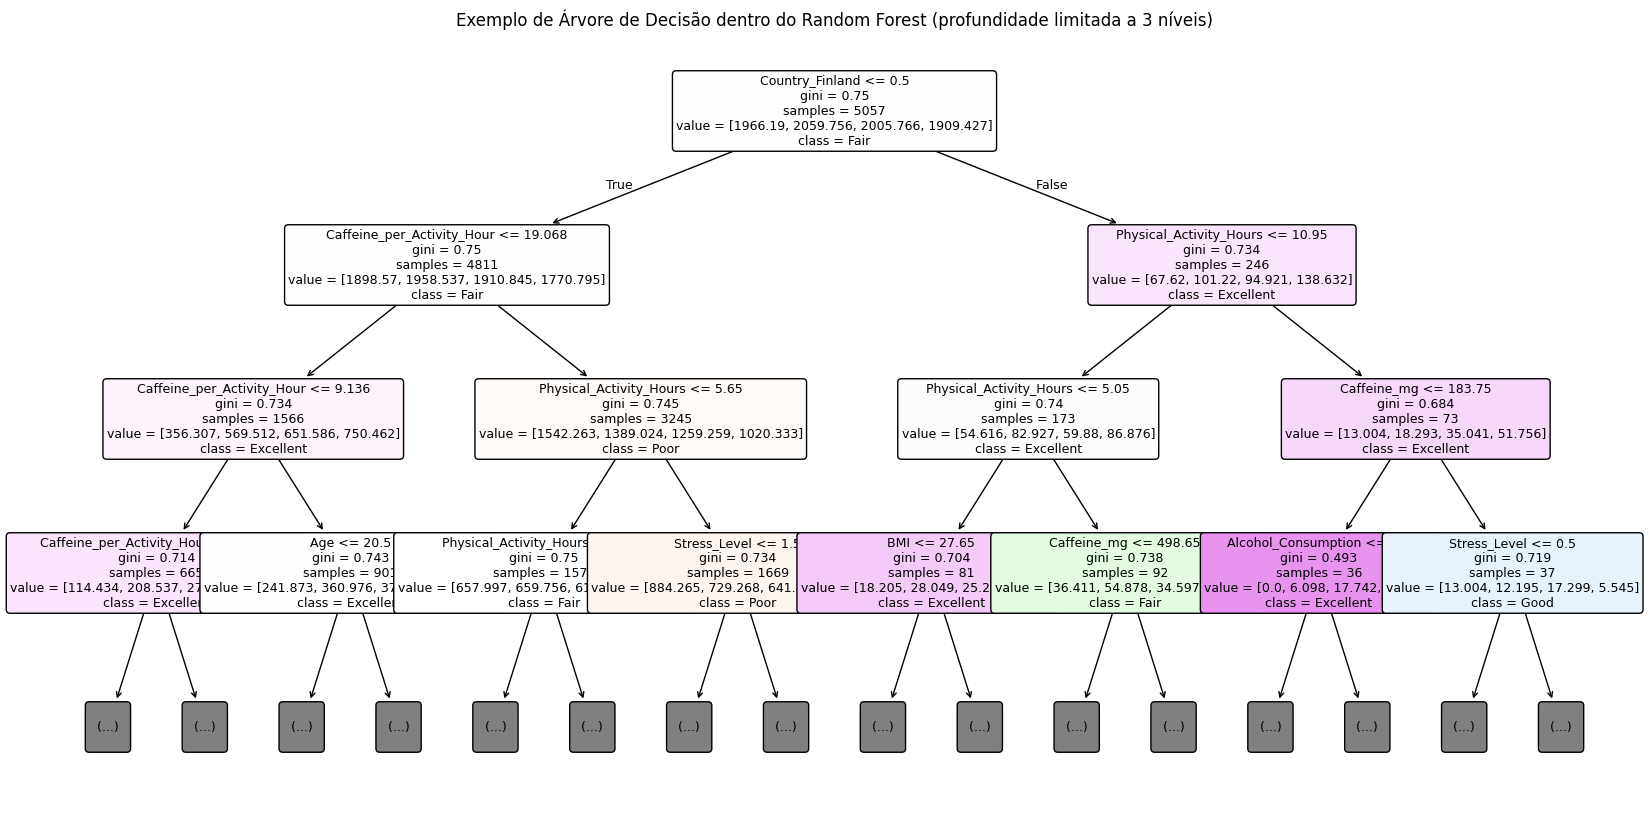

In [129]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    modelo_rf_balanced.estimators_[0],
    feature_names=X_train.columns,
    class_names=nomes_classes,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)
plt.title('Exemplo de Árvore de Decisão dentro do Random Forest (profundidade limitada a 3 níveis)')
plt.show()

# Avaliação dos Modelos

### Qual modelo performou melhor?

Antes de comparar os modelos, foi identificado um problema de **vazamento de dado**
(data leakage): a coluna `Sleep_Hours` tinha uma relação quase determinística com o
alvo `Sleep_Quality` (faixas de horas de sono sem sobreposição entre as categorias),
o que fazia os modelos atingirem acurácia de ~99% ao "decorar" essa regra, em vez de
aprender padrões reais de hábito. Após remover `Sleep_Hours` e refazer a feature
derivada sem depender dela, a acurácia caiu para um patamar mais realista:

| Modelo | Acurácia (sem balanceamento) | Acurácia (com class_weight='balanced') |
|---|---|---|
| Regressão Logística | 86,5% | 67,4% |
| Random Forest | 86,4% | 86,55% |

Sem balanceamento, os dois modelos empataram tecnicamente em acurácia geral, mas
**nenhum dos dois conseguia prever a classe "Excellent"** (recall 0.00), o modelo
sempre "chutava" a classe majoritária (Good) quando estava em dúvida, já que essa
estratégia maximiza a acurácia geral em um dataset desbalanceado.

Ao aplicar `class_weight='balanced'`, os dois modelos reagiram de forma bem
diferente:
- A **Regressão Logística** passou a identificar 55% dos casos reais de "Excellent"
(recall 0.55), mas pagou o preço de acurácia geral cair para 67,4%.
- O **Random Forest** praticamente ignorou o balanceamento (recall de "Excellent"
continuou perto de 0), mantendo a acurácia alta às custas de nunca arriscar prever
a classe minoritária.

**Conclusão:** não há um "melhor modelo" único — depende do objetivo de negócio.
Se o critério é acurácia geral, o Random Forest balanceado (86,55%) é a escolha.
Se o objetivo é identificar clientes com sono "Excellent" (por exemplo, para
entender o que esses clientes fazem de diferente), a Regressão Logística balanceada
é o único modelo que realmente enxerga essa classe, mesmo com acurácia geral menor.

### Há overfitting ou underfitting?

Não foi observado overfitting ou underfitting no sentido clássico (os modelos não
"decoraram" o treino nem falharam em capturar padrões básicos). O problema
identificado foi um **viés por desbalanceamento de classes**: como "Good" é a
categoria mais frequente no dataset (mais de 56% dos registros), os modelos
aprenderam que prever essa classe na dúvida maximiza a acurácia geral, o que
prejudicou o desempenho nas classes minoritárias, principalmente "Excellent"
(13,5% dos registros).

#Salvando o dataset processado

In [130]:
dados_final = X.copy()
dados_final['Sleep_Quality'] = y

dados_final.to_csv('dataset_processado_final.csv', index=False)

print("Dataset salvo com sucesso.")
print("Shape final:", dados_final.shape)

Dataset salvo com sucesso.
Shape final: (10000, 36)


#Salvando melhor modelo

In [131]:
import joblib

joblib.dump(modelo_rf_balanced, 'modelo_sleep_quality_rf.pkl')

print("Modelo salvo com sucesso.")

Modelo salvo com sucesso.


In [132]:
importancias_finais = pd.Series(modelo_rf_balanced.feature_importances_, index=X_train.columns)
importancias_finais.sort_values(ascending=False).head(10)

,0
Stress_Level,0.509626
Caffeine_mg,0.057421
BMI,0.054901
Caffeine_per_Activity_Hour,0.054857
Physical_Activity_Hours,0.052712
Heart_Rate,0.048289
Age,0.047968
Coffee_Intake,0.041871
Gender_Male,0.010749
Alcohol_Consumption,0.009458


# Recomendações para o Negócio

O modelo preditivo identificou que o **nível de estresse** é, disparadamente, o
fator mais relevante para prever a qualidade do sono dos clientes (50,9% de
importância no modelo), superando com folga variáveis relacionadas ao consumo de
café e cafeína (juntas, pouco mais de 10%). Isso é consistente com o que já havia
sido observado na análise exploratória (Parte 2), onde o estresse mostrou relação
direta e forte com as horas de sono, enquanto o café mostrou uma relação mais
sutil.

**Implicações práticas para a Health&Life Analytics:**

1. **Priorizar o manejo de estresse em vez de restrição de café.** Como o estresse
tem impacto muito maior sobre o sono do que o consumo de cafeína, orientações
focadas exclusivamente em "reduzir café" tendem a ter efeito limitado se não
vierem acompanhadas de estratégias de controle de estresse (ex: técnicas de
relaxamento, pausas, atividade física).

2. **Usar o consumo de café como sinal complementar, não como causa principal.**
O café pode ser útil como um indicador secundário de risco (clientes com alto
consumo de cafeína tendem a estar em grupos de maior estresse), mas orientações
de produto ou conteúdo não devem tratar o café como o principal vilão do sono
ruim.

3. **Segmentar recomendações por nível de estresse do cliente.** Como o modelo
consegue prever com boa confiabilidade as classes de sono "Poor" e "Fair"
(recall de 1.00 em ambas), a empresa pode usar essa previsão para identificar
proativamente clientes em risco de sono ruim e direcionar conteúdo ou
intervenções personalizadas antes mesmo de aplicar uma pesquisa de satisfação
com o cliente.

4. **Cautela com a classe "Excellent".** O modelo ainda tem dificuldade em
identificar clientes com sono excelente de forma confiável. Isso significa que,
por ora, o modelo é mais indicado para identificar clientes em risco (Poor/Fair)
do que para replicar hábitos de clientes com sono ideal.